<a href="https://colab.research.google.com/github/rruchita08-web/Customer-Transaction-Prediction-Project/blob/main/House_Price_detection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# House Price Prediction using Machine Learning

### Problem Statement

The objective of this project is to analyze the housing dataset and build a machine learning model to predict house prices based on various house features. Multiple regression algorithms are implemented and compared to identify the best-performing model.

In [ ]:
# ===============================
# Import Required Libraries
# ===============================

# Data Manipulation
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Ignore warnings
import warnings
warnings.filterwarnings('ignore')

# Display all columns
pd.set_option('display.max_columns', None)

print("Libraries Imported Successfully!")

Libraries Imported Successfully!


In [ ]:
import pandas as pd

df = pd.read_csv("/content/data.csv")

In [ ]:
df.head()


,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,Condition1,Condition2,BldgType,HouseStyle,OverallQual,OverallCond,YearBuilt,YearRemodAdd,RoofStyle,RoofMatl,Exterior1st,Exterior2nd,MasVnrType,MasVnrArea,ExterQual,ExterCond,Foundation,BsmtQual,BsmtCond,BsmtExposure,BsmtFinType1,BsmtFinSF1,BsmtFinType2,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,Heating,HeatingQC,CentralAir,Electrical,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,KitchenQual,TotRmsAbvGrd,Functional,Fireplaces,FireplaceQu,GarageType,GarageYrBlt,GarageFinish,GarageCars,GarageArea,GarageQual,GarageCond,PavedDrive,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2003,2003,Gable,CompShg,VinylSd,VinylSd,BrkFace,196.0,Gd,TA,PConc,Gd,TA,No,GLQ,706,Unf,0,150,856,GasA,Ex,Y,SBrkr,856,854,0,1710,1,0,2,1,3,1,Gd,8,Typ,0,NaN,Attchd,2003.0,RFn,2,548,TA,TA,Y,0,61,0,0,0,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,FR2,Gtl,Veenker,Feedr,Norm,1Fam,1Story,6,8,1976,1976,Gable,CompShg,MetalSd,MetalSd,NaN,0.0,TA,TA,CBlock,Gd,TA,Gd,ALQ,978,Unf,0,284,1262,GasA,Ex,Y,SBrkr,1262,0,0,1262,0,1,2,0,3,1,TA,6,Typ,1,TA,Attchd,1976.0,RFn,2,460,TA,TA,Y,298,0,0,0,0,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2001,2002,Gable,CompShg,VinylSd,VinylSd,BrkFace,162.0,Gd,TA,PConc,Gd,TA,Mn,GLQ,486,Unf,0,434,920,GasA,Ex,Y,SBrkr,920,866,0,1786,1,0,2,1,3,1,Gd,6,Typ,1,TA,Attchd,2001.0,RFn,2,608,TA,TA,Y,0,42,0,0,0,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,Corner,Gtl,Crawfor,Norm,Norm,1Fam,2Story,7,5,1915,1970,Gable,CompShg,Wd Sdng,Wd Shng,NaN,0.0,TA,TA,BrkTil,TA,Gd,No,ALQ,216,Unf,0,540,756,GasA,Gd,Y,SBrkr,961,756,0,1717,1,0,1,0,3,1,Gd,7,Typ,1,Gd,Detchd,1998.0,Unf,3,642,TA,TA,Y,0,35,272,0,0,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,FR2,Gtl,NoRidge,Norm,Norm,1Fam,2Story,8,5,2000,2000,Gable,CompShg,VinylSd,VinylSd,BrkFace,350.0,Gd,TA,PConc,Gd,TA,Av,GLQ,655,Unf,0,490,1145,GasA,Ex,Y,SBrkr,1145,1053,0,2198,1,0,2,1,4,1,Gd,9,Typ,1,TA,Attchd,2000.0,RFn,3,836,TA,TA,Y,192,84,0,0,0,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [ ]:
print("Dataset Shape:", df.shape)


Dataset Shape: (1460, 81)


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   object 
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   object 
 6   Alley          91 non-null     object 
 7   LotShape       1460 non-null   object 
 8   LandContour    1460 non-null   object 
 9   Utilities      1460 non-null   object 
 10  LotConfig      1460 non-null   object 
 11  LandSlope      1460 non-null   object 
 12  Neighborhood   1460 non-null   object 
 13  Condition1     1460 non-null   object 
 14  Condition2     1460 non-null   object 
 15  BldgType       1460 non-null   object 
 16  HouseStyle     1460 non-null   object 
 17  OverallQual    1460 non-null   int64  
 18  OverallC

In [ ]:
df.describe()

,Id,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,TotRmsAbvGrd,Fireplaces,GarageYrBlt,GarageCars,GarageArea,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SalePrice
count,1460.000000,1460.000000,1201.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1452.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1379.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000
mean,730.500000,56.897260,70.049958,10516.828082,6.099315,5.575342,1971.267808,1984.865753,103.685262,443.639726,46.549315,567.240411,1057.429452,1162.626712,346.992466,5.844521,1515.463699,0.425342,0.057534,1.565068,0.382877,2.866438,1.046575,6.517808,0.613014,1978.506164,1.767123,472.980137,94.244521,46.660274,21.954110,3.409589,15.060959,2.758904,43.489041,6.321918,2007.815753,180921.195890
std,421.610009,42.300571,24.284752,9981.264932,1.382997,1.112799,30.202904,20.645407,181.066207,456.098091,161.319273,441.866955,438.705324,386.587738,436.528436,48.623081,525.480383,0.518911,0.238753,0.550916,0.502885,0.815778,0.220338,1.625393,0.644666,24.689725,0.747315,213.804841,125.338794,66.256028,61.119149,29.317331,55.757415,40.177307,496.123024,2.703626,1.328095,79442.502883
min,1.000000,20.000000,21.000000,1300.000000,1.000000,1.000000,1872.000000,1950.000000,0.000000,0.000000,0.000000,0.000000,0.000000,334.000000,0.000000,0.000000,334.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2.000000,0.000000,1900.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,2006.000000,34900.000000
25%,365.750000,20.000000,59.000000,7553.500000,5.000000,5.000000,1954.000000,1967.000000,0.000000,0.000000,0.000000,223.000000,795.750000,882.000000,0.000000,0.000000,1129.500000,0.000000,0.000000,1.000000,0.000000,2.000000,1.000000,5.000000,0.000000,1961.000000,1.000000,334.500000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,5.000000,2007.000000,129975.000000
50%,730.500000,50.000000,69.000000,9478.500000,6.000000,5.000000,1973.000000,1994.000000,0.000000,383.500000,0.000000,477.500000,991.500000,1087.000000,0.000000,0.000000,1464.000000,0.000000,0.000000,2.000000,0.000000,3.000000,1.000000,6.000000,1.000000,1980.000000,2.000000,480.000000,0.000000,25.000000,0.000000,0.000000,0.000000,0.000000,0.000000,6.000000,2008.000000,163000.000000
75%,1095.250000,70.000000,80.000000,11601.500000,7.000000,6.000000,2000.000000,2004.000000,166.000000,712.250000,0.000000,808.000000,1298.250000,1391.250000,728.000000,0.000000,1776.750000,1.000000,0.000000,2.000000,1.000000,3.000000,1.000000,7.000000,1.000000,2002.000000,2.000000,576.000000,168.000000,68.000000,0.000000,0.000000,0.000000,0.000000,0.000000,8.000000,2009.000000,214000.000000
max,1460.000000,190.000000,313.000000,215245.000000,10.000000,9.000000,2010.000000,2010.000000,1600.000000,5644.000000,1474.000000,2336.000000,6110.000000,4692.000000,2065.000000,572.000000,5642.000000,3.000000,2.000000,3.000000,2.000000,8.000000,3.000000,14.000000,3.000000,2010.000000,4.000000,1418.000000,857.000000,547.000000,552.000000,508.000000,480.000000,738.000000,15500.000000,12.000000,2010.000000,755000.000000


### Observation

The dataset contains 1460 records and 81 features. It consists of both numerical and categorical variables, with missing values present in several columns.

In [ ]:
missing = df.isnull().sum()
missing = missing[missing > 0]
missing.sort_values(ascending=False)

,0
PoolQC,1453
MiscFeature,1406
Alley,1369
Fence,1179
MasVnrType,872
FireplaceQu,690
LotFrontage,259
GarageType,81
GarageYrBlt,81
GarageFinish,81


In [ ]:
df.duplicated().sum()


np.int64(0)

In [ ]:
from sklearn.model_selection import train_test_split

X = df.drop("SalePrice", axis=1)
y = df["SalePrice"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [ ]:
# Missing values in X_train

missing_values = X_train.isnull().sum()
missing_values = missing_values[missing_values > 0]

missing_values.sort_values(ascending=False)

,0
PoolQC,1162
MiscFeature,1122
Alley,1094
Fence,935
MasVnrType,683
FireplaceQu,547
LotFrontage,217
GarageType,64
GarageYrBlt,64
GarageFinish,64


In [ ]:
missing_values.sort_values(ascending=False)

,0
PoolQC,1162
MiscFeature,1122
Alley,1094
Fence,935
MasVnrType,683
FireplaceQu,547
LotFrontage,217
GarageType,64
GarageYrBlt,64
GarageFinish,64


In [ ]:
# Numerical columns
num_cols = X_train.select_dtypes(include=['int64', 'float64']).columns

In [ ]:
# Fill missing numerical values with median

for col in num_cols:
    median = X_train[col].median()
    X_train[col].fillna(median, inplace=True)
    X_test[col].fillna(median, inplace=True)

In [ ]:
# Categorical columns
cat_cols = X_train.select_dtypes(include=['object']).columns

In [ ]:
# Fill missing categorical values with mode

for col in cat_cols:
    mode = X_train[col].mode()[0]
    X_train[col].fillna(mode, inplace=True)
    X_test[col].fillna(mode, inplace=True)

In [ ]:
print("Missing values in X_train:", X_train.isnull().sum().sum())
print("Missing values in X_test :", X_test.isnull().sum().sum())

Missing values in X_train: 0
Missing values in X_test : 0


In [ ]:
print(X_train.isnull().sum().sum())
print(X_test.isnull().sum().sum())

0
0


In [ ]:
# One-Hot Encoding

X_train = pd.get_dummies(X_train, drop_first=True)
X_test = pd.get_dummies(X_test, drop_first=True)

In [ ]:
# Align train and test datasets

X_train, X_test = X_train.align(
    X_test,
    join='left',
    axis=1,
    fill_value=0
)

In [ ]:
print("Training Data Shape :", X_train.shape)
print("Testing Data Shape  :", X_test.shape)

Training Data Shape : (1168, 243)
Testing Data Shape  : (292, 243)


In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

In [ ]:
# Create the model
lr_model = LinearRegression()

# Train the model
lr_model.fit(X_train, y_train)

LinearRegression()

In [ ]:
# Predict house prices
y_pred_lr = lr_model.predict(X_test)

In [ ]:
# Evaluation Metrics

mae_lr = mean_absolute_error(y_test, y_pred_lr)
mse_lr = mean_squared_error(y_test, y_pred_lr)
rmse_lr = np.sqrt(mse_lr)
r2_lr = r2_score(y_test, y_pred_lr)

print("Linear Regression Performance")
print("-" * 35)
print("MAE :", mae_lr)
print("MSE :", mse_lr)
print("RMSE:", rmse_lr)
print("R² Score:", r2_lr)

Linear Regression Performance
-----------------------------------
MAE : 623783.1556390726
MSE : 397604684138.77826
RMSE: 630559.0251029464
R² Score: -50.83673723892227


In [ ]:
comparison = pd.DataFrame({
    'Actual Price': y_test,
    'Predicted Price': y_pred_lr
})

comparison.head(10)

,Actual Price,Predicted Price
892,154500,-486748.689395
1105,325000,-295661.476385
413,115000,-536400.183588
522,159000,-448711.359968
1036,315500,-327489.970449
614,75500,-577736.309737
218,311500,-408603.368144
1160,146000,-498125.098906
649,84500,-586858.366130
887,135500,-490374.940748


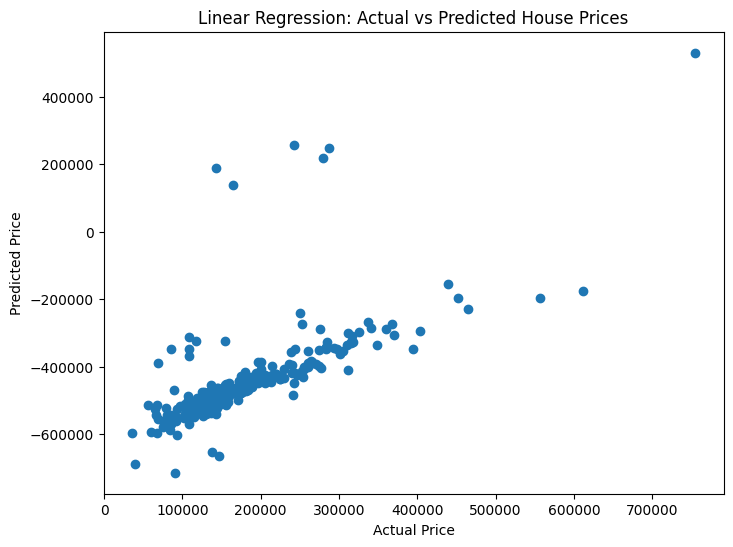

In [ ]:
plt.figure(figsize=(8,6))

plt.scatter(y_test, y_pred_lr)

plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Linear Regression: Actual vs Predicted House Prices")

plt.show()

In [ ]:
y_train.describe()

,SalePrice
count,1168.000000
mean,181441.541952
std,77263.583862
min,34900.000000
25%,130000.000000
50%,165000.000000
75%,214925.000000
max,745000.000000


In [ ]:
y_test.describe()

,SalePrice
count,292.000000
mean,178839.811644
std,87730.751259
min,35311.000000
25%,127000.000000
50%,154150.000000
75%,209175.000000
max,755000.000000


In [ ]:
print(X_train.isnull().sum().sum())
print(X_test.isnull().sum().sum())

0
0


In [ ]:
X_train.dtypes.value_counts()

,count
bool,206
int64,34
float64,3


In [ ]:
print(y_pred_lr[:10])

[-486748.68939459 -295661.47638489 -536400.18358773 -448711.35996838
 -327489.97044942 -577736.30973736 -408603.36814428 -498125.09890618
 -586858.36613008 -490374.94074812]


In [ ]:
X_train.iloc[:5, :10]

,Id,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1
254,255,20,70.0,8400,5,6,1957,1957,0.0,922
1066,1067,60,59.0,7837,6,7,1993,1994,0.0,0
638,639,30,67.0,8777,5,7,1910,1950,0.0,0
799,800,50,60.0,7200,5,7,1937,1950,252.0,569
380,381,50,50.0,5000,5,6,1924,1950,0.0,218


In [ ]:
X = df.drop("SalePrice", axis=1)
y = df["SalePrice"]

In [ ]:
# Numerical columns
num_cols = X.select_dtypes(include=['int64', 'float64']).columns

# Fill missing numerical values with median
for col in num_cols:
    X[col].fillna(X[col].median(), inplace=True)

In [ ]:
# Categorical columns
cat_cols = X.select_dtypes(include=['object']).columns

# Fill missing categorical values with mode
for col in cat_cols:
    X[col].fillna(X[col].mode()[0], inplace=True)

In [ ]:
print(X.isnull().sum().sum())

0


In [ ]:
X = pd.get_dummies(X, drop_first=True)

In [ ]:
bool_cols = X.select_dtypes(include='bool').columns

X[bool_cols] = X[bool_cols].astype(int)

In [ ]:
X.dtypes.value_counts()

,count
int64,242
float64,3


In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [ ]:
print(X_train.shape)
print(X_test.shape)

(1168, 245)
(292, 245)


In [ ]:
X.dtypes.value_counts()

,count
int64,242
float64,3


In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

In [ ]:
# Create Linear Regression model
lr_model = LinearRegression()

# Train the model
lr_model.fit(X_train, y_train)

LinearRegression()

In [ ]:
# Predict on test data
y_pred_lr = lr_model.predict(X_test)

In [ ]:
# Model Evaluation

mae_lr = mean_absolute_error(y_test, y_pred_lr)
mse_lr = mean_squared_error(y_test, y_pred_lr)
rmse_lr = np.sqrt(mse_lr)
r2_lr = r2_score(y_test, y_pred_lr)

print("Linear Regression Performance")
print("-"*35)
print("MAE :", round(mae_lr,2))
print("MSE :", round(mse_lr,2))
print("RMSE:", round(rmse_lr,2))
print("R2 Score:", round(r2_lr,4))

Linear Regression Performance
-----------------------------------
MAE : 20232.18
MSE : 2642483715.19
RMSE: 51405.09
R2 Score: 0.6555


In [ ]:
comparison = pd.DataFrame({
    "Actual Price": y_test,
    "Predicted Price": y_pred_lr
})

comparison.head(10)

,Actual Price,Predicted Price
892,154500,157784.948994
1105,325000,349289.180579
413,115000,86449.665051
522,159000,174007.557439
1036,315500,317396.249840
614,75500,66731.088733
218,311500,235626.508044
1160,146000,146348.050121
649,84500,57726.419479
887,135500,153865.384279


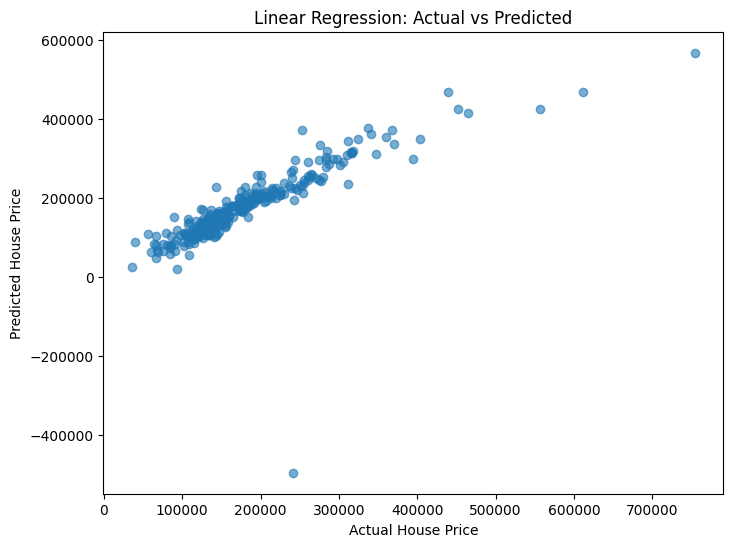

In [ ]:
plt.figure(figsize=(8,6))
plt.scatter(y_test, y_pred_lr, alpha=0.6)
plt.xlabel("Actual House Price")
plt.ylabel("Predicted House Price")
plt.title("Linear Regression: Actual vs Predicted")
plt.show()

In [ ]:
from sklearn.ensemble import RandomForestRegressor

In [ ]:
# Create Random Forest model

rf_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

# Train the model

rf_model.fit(X_train, y_train)

RandomForestRegressor(random_state=42)

In [ ]:
y_pred_rf = rf_model.predict(X_test)

In [ ]:
mae_rf = mean_absolute_error(y_test, y_pred_rf)
mse_rf = mean_squared_error(y_test, y_pred_rf)
rmse_rf = np.sqrt(mse_rf)
r2_rf = r2_score(y_test, y_pred_rf)

print("Random Forest Performance")
print("-"*35)
print("MAE :", round(mae_rf,2))
print("MSE :", round(mse_rf,2))
print("RMSE:", round(rmse_rf,2))
print("R2 Score:", round(r2_rf,4))

Random Forest Performance
-----------------------------------
MAE : 17481.78
MSE : 803842286.93
RMSE: 28352.11
R2 Score: 0.8952


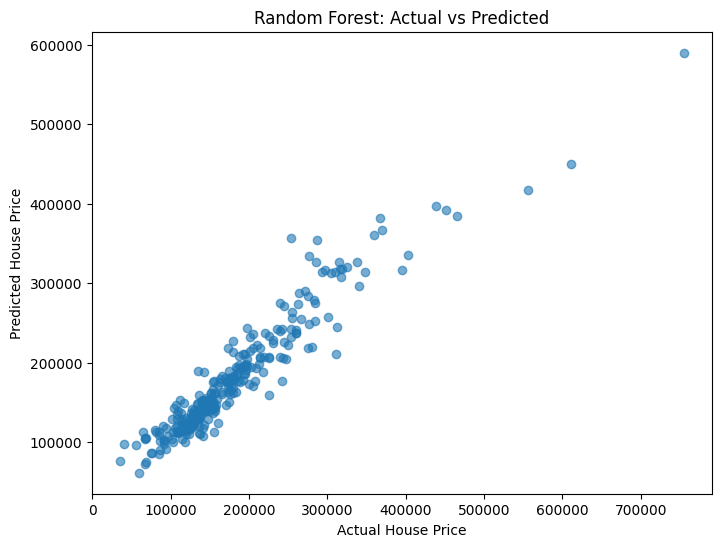

In [ ]:
plt.figure(figsize=(8,6))

plt.scatter(y_test, y_pred_rf, alpha=0.6)

plt.xlabel("Actual House Price")
plt.ylabel("Predicted House Price")
plt.title("Random Forest: Actual vs Predicted")

plt.show()

### Random Forest Model Evaluation

The Random Forest Regressor achieved an **R² Score of 0.8952**, which indicates that the model explains **89.52% of the variance** in house prices.

Compared to Linear Regression, Random Forest produced:
- Lower Mean Absolute Error (MAE)
- Lower Root Mean Squared Error (RMSE)
- Higher R² Score

This demonstrates that Random Forest is more effective in capturing the complex relationships between house features and sale prices.

In [ ]:
from sklearn.ensemble import GradientBoostingRegressor

In [ ]:
# Create Gradient Boosting model
gb_model = GradientBoostingRegressor(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=3,
    random_state=42
)

# Train the model
gb_model.fit(X_train, y_train)

GradientBoostingRegressor(random_state=42)

In [ ]:
# Predict
y_pred_gb = gb_model.predict(X_test)

In [ ]:
mae_gb = mean_absolute_error(y_test, y_pred_gb)
mse_gb = mean_squared_error(y_test, y_pred_gb)
rmse_gb = np.sqrt(mse_gb)
r2_gb = r2_score(y_test, y_pred_gb)

print("Gradient Boosting Performance")
print("-" * 35)
print("MAE :", round(mae_gb, 2))
print("MSE :", round(mse_gb, 2))
print("RMSE:", round(rmse_gb, 2))
print("R2 Score:", round(r2_gb, 4))

Gradient Boosting Performance
-----------------------------------
MAE : 17458.61
MSE : 787779149.97
RMSE: 28067.4
R2 Score: 0.8973


In [ ]:
# Create Model Comparison Table

model_comparison = pd.DataFrame({
    'Model': ['Linear Regression', 'Random Forest', 'Gradient Boosting'],
    'MAE': [mae_lr, mae_rf, mae_gb],
    'RMSE': [rmse_lr, rmse_rf, rmse_gb],
    'R2 Score': [r2_lr, r2_rf, r2_gb]
})

model_comparison

,Model,MAE,RMSE,R2 Score
0,Linear Regression,20232.175888,51405.094253,0.655493
1,Random Forest,17481.776644,28352.112566,0.895201
2,Gradient Boosting,17458.613829,28067.403691,0.897295


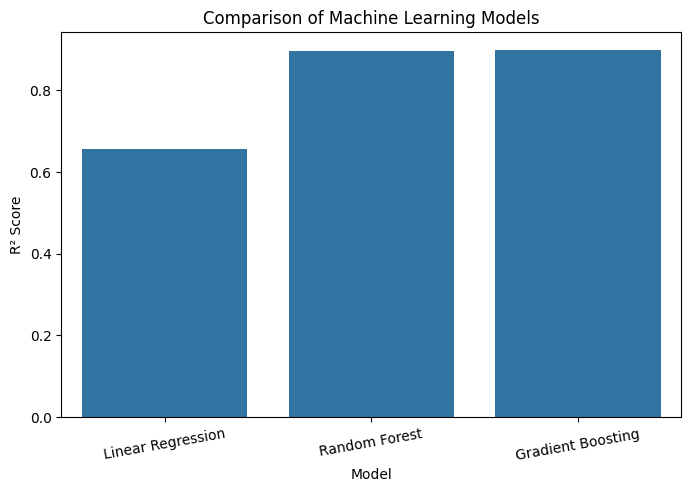

In [ ]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=model_comparison,
    x='Model',
    y='R2 Score'
)

plt.title("Comparison of Machine Learning Models")
plt.ylabel("R² Score")
plt.xticks(rotation=10)

plt.show()

In [ ]:
feature_importance = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': gb_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by='Importance',
    ascending=False
)

feature_importance.head(10)

,Feature,Importance
4,OverallQual,0.513283
16,GrLivArea,0.157892
26,GarageCars,0.049224
12,TotalBsmtSF,0.045216
9,BsmtFinSF1,0.036196
13,1stFlrSF,0.031729
14,2ndFlrSF,0.025530
3,LotArea,0.014693
6,YearBuilt,0.014348
213,GarageFinish_Unf,0.014137


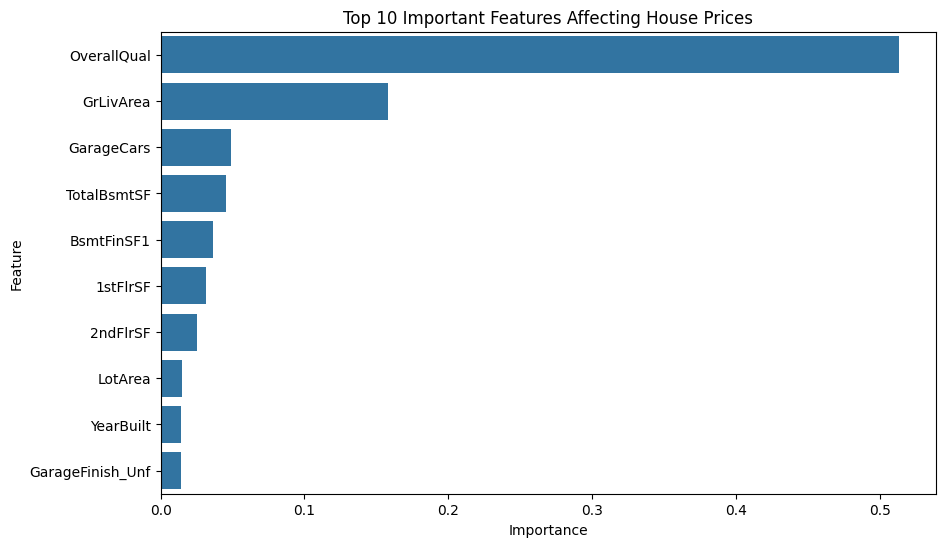

In [ ]:
plt.figure(figsize=(10,6))

sns.barplot(
    data=feature_importance.head(10),
    x='Importance',
    y='Feature'
)

plt.title("Top 10 Important Features Affecting House Prices")

plt.show()

In [ ]:
# Top 10 correlated features with SalePrice

corr = df.corr(numeric_only=True)

top_features = corr['SalePrice'].sort_values(
    ascending=False
).head(11)

print(top_features)

SalePrice       1.000000
OverallQual     0.790982
GrLivArea       0.708624
GarageCars      0.640409
GarageArea      0.623431
TotalBsmtSF     0.613581
1stFlrSF        0.605852
FullBath        0.560664
TotRmsAbvGrd    0.533723
YearBuilt       0.522897
YearRemodAdd    0.507101
Name: SalePrice, dtype: float64


In [ ]:
from sklearn.model_selection import GridSearchCV

In [ ]:
param_grid = {
    'n_estimators': [100, 200],
    'learning_rate': [0.05, 0.1],
    'max_depth': [3, 4],
    'min_samples_split': [2, 5]
}

In [ ]:
grid_search = GridSearchCV(
    estimator=GradientBoostingRegressor(random_state=42),
    param_grid=param_grid,
    cv=5,
    scoring='r2',
    n_jobs=-1
)

In [ ]:
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.model_selection import GridSearchCV

In [ ]:
param_grid = {
    'n_estimators': [100, 200],
    'learning_rate': [0.05, 0.1],
    'max_depth': [3, 4],
    'min_samples_split': [2, 5]
}

In [ ]:
grid_search = GridSearchCV(
    estimator=GradientBoostingRegressor(random_state=42),
    param_grid=param_grid,
    cv=5,
    scoring='r2',
    n_jobs=-1
)

In [ ]:
grid_search.fit(X_train, y_train)

GridSearchCV(cv=5, estimator=GradientBoostingRegressor(random_state=42),
             n_jobs=-1,
             param_grid={'learning_rate': [0.05, 0.1], 'max_depth': [3, 4],
                         'min_samples_split': [2, 5],
                         'n_estimators': [100, 200]},
             scoring='r2')

In [ ]:
print("Best Parameters:")
print(grid_search.best_params_)

Best Parameters:
{'learning_rate': 0.1, 'max_depth': 3, 'min_samples_split': 2, 'n_estimators': 200}


In [ ]:
best_gb = grid_search.best_estimator_

In [ ]:
y_pred_best = best_gb.predict(X_test)

In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

mae_best = mean_absolute_error(y_test, y_pred_best)
mse_best = mean_squared_error(y_test, y_pred_best)
rmse_best = np.sqrt(mse_best)
r2_best = r2_score(y_test, y_pred_best)

print("Tuned Gradient Boosting Performance")
print("-" * 40)
print("MAE :", round(mae_best, 2))
print("RMSE:", round(rmse_best, 2))
print("R2 Score:", round(r2_best, 4))

Tuned Gradient Boosting Performance
----------------------------------------
MAE : 16895.43
RMSE: 27539.59
R2 Score: 0.9011


In [ ]:
comparison = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Random Forest",
        "Gradient Boosting",
        "Tuned Gradient Boosting"
    ],
    "MAE": [
        mae_lr,
        mae_rf,
        mae_gb,
        mae_best
    ],
    "RMSE": [
        rmse_lr,
        rmse_rf,
        rmse_gb,
        rmse_best
    ],
    "R2 Score": [
        r2_lr,
        r2_rf,
        r2_gb,
        r2_best
    ]
})

comparison.sort_values(by="R2 Score", ascending=False)

,Model,MAE,RMSE,R2 Score
3,Tuned Gradient Boosting,16895.428610,27539.589301,0.901122
2,Gradient Boosting,17458.613829,28067.403691,0.897295
1,Random Forest,17481.776644,28352.112566,0.895201
0,Linear Regression,20232.175888,51405.094253,0.655493


In [ ]:
print(grid_search.best_params_)

{'learning_rate': 0.1, 'max_depth': 3, 'min_samples_split': 2, 'n_estimators': 200}


In [ ]:
print(round(r2_best,4))

0.9011


In [ ]:
model_comparison = pd.DataFrame({
    'Model': [
        'Linear Regression',
        'Random Forest',
        'Gradient Boosting',
        'Tuned Gradient Boosting'
    ],
    'R2 Score': [
        0.6555,
        0.8952,
        0.8973,
        0.9011
    ]
})

model_comparison.sort_values(by='R2 Score', ascending=False)

,Model,R2 Score
3,Tuned Gradient Boosting,0.9011
2,Gradient Boosting,0.8973
1,Random Forest,0.8952
0,Linear Regression,0.6555


## Best Model

Among all the models, the Tuned Gradient Boosting Regressor achieved the highest R² Score of **0.9011**.

Therefore, it is selected as the final model for predicting house prices.

In [ ]:
import pandas as pd

model_comparison = pd.DataFrame({
    'Model': [
        'Linear Regression',
        'Random Forest',
        'Gradient Boosting',
        'Tuned Gradient Boosting'
    ],
    'MAE': [
        20232.18,
        17481.78,
        17458.61,
        round(mae_best, 2)
    ],
    'RMSE': [
        51405.09,
        28352.11,
        28067.40,
        round(rmse_best, 2)
    ],
    'R2 Score': [
        0.6555,
        0.8952,
        0.8973,
        round(r2_best, 4)
    ]
})

model_comparison

,Model,MAE,RMSE,R2 Score
0,Linear Regression,20232.18,51405.09,0.6555
1,Random Forest,17481.78,28352.11,0.8952
2,Gradient Boosting,17458.61,28067.40,0.8973
3,Tuned Gradient Boosting,16895.43,27539.59,0.9011


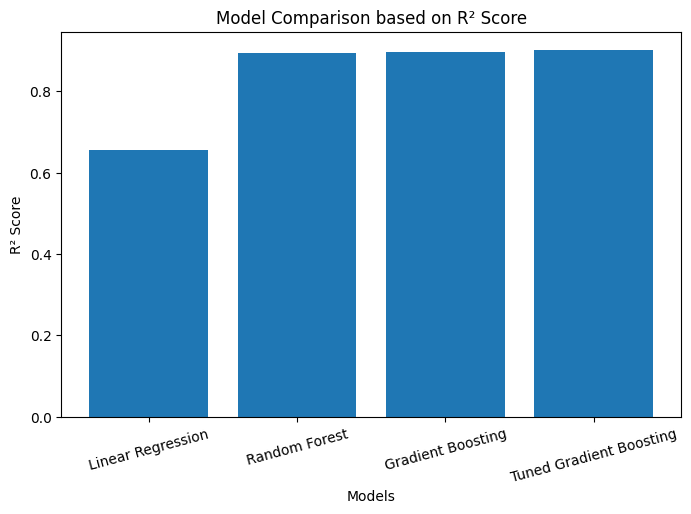

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.bar(model_comparison['Model'], model_comparison['R2 Score'])

plt.title("Model Comparison based on R² Score")
plt.xlabel("Models")
plt.ylabel("R² Score")

plt.xticks(rotation=15)

plt.show()

In [ ]:
feature_importance = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': best_gb.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by='Importance',
    ascending=False
)

feature_importance.head(10)

,Feature,Importance
4,OverallQual,0.507061
16,GrLivArea,0.156269
26,GarageCars,0.048663
12,TotalBsmtSF,0.045234
9,BsmtFinSF1,0.036228
13,1stFlrSF,0.031608
14,2ndFlrSF,0.025431
3,LotArea,0.014838
6,YearBuilt,0.014422
213,GarageFinish_Unf,0.013960


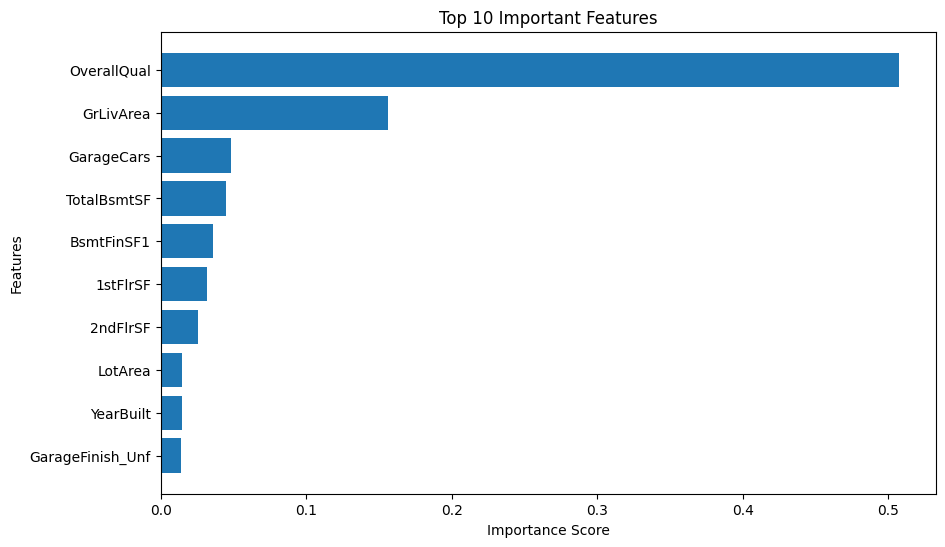

In [ ]:
plt.figure(figsize=(10,6))

top10 = feature_importance.head(10)

plt.barh(top10['Feature'], top10['Importance'])

plt.xlabel("Importance Score")
plt.ylabel("Features")
plt.title("Top 10 Important Features")

plt.gca().invert_yaxis()

plt.show()

## Conclusion

This project developed and evaluated multiple machine learning models to predict house prices using the Ames Housing dataset.

The following models were implemented:
- Linear Regression
- Random Forest Regressor
- Gradient Boosting Regressor
- Tuned Gradient Boosting Regressor

Hyperparameter tuning was performed using GridSearchCV to improve the performance of the Gradient Boosting model.

Among all the models, the Tuned Gradient Boosting Regressor achieved the best performance with an R² Score of **0.9011**, indicating that the model explains approximately **90.11%** of the variation in house prices.

The analysis also showed that features such as **Overall Quality, Living Area, Garage Capacity, Basement Area, and Neighborhood** have a significant influence on house prices.

Therefore, the Tuned Gradient Boosting Regressor is selected as the final model for predicting house prices due to its high accuracy and strong predictive performance.

## Customer Recommendations

Based on the analysis and the best-performing model, the following recommendations are provided:

1. Houses with higher overall quality generally have higher market values.
2. Larger living areas are strongly associated with increased sale prices.
3. Properties with larger garages and finished basements tend to command higher prices.
4. Location and neighborhood should be carefully considered, as they significantly influence property values.
5. Buyers should balance their budget with important features such as quality, living area, and garage space to maximize value.

## Challenges Faced

- Handling missing values in both numerical and categorical variables.
- Converting categorical variables into numerical format using One-Hot Encoding.
- Ensuring training and testing datasets had identical feature columns after encoding.
- Selecting the optimal machine learning model by comparing multiple evaluation metrics.
- Improving model performance through hyperparameter tuning using GridSearchCV.